In [2]:
# 1. httpx 버전을 다시 높여서 주피터랩 복구
!pip install "httpx>=0.25.0"

# 2. googletrans 대신 의존성 문제가 적은 deep-translator 설치
!pip install deep-translator

  Attempting uninstall: h11
    Found existing installation: h11 0.9.0
    Uninstalling h11-0.9.0:
      Successfully uninstalled h11-0.9.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.9.1
    Uninstalling httpcore-0.9.1:
      Successfully uninstalled httpcore-0.9.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.13.3
    Uninstalling httpx-0.13.3:
      Successfully uninstalled httpx-0.13.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [httpx]32m2/3 [httpx]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googletrans 4.0.0rc1 requires httpx==0.13.3, but you have httpx 0.28.1 which is incompatible.


In [3]:
import pandas as pd
import random

# 1. 데이터 로드
# 모델 학습에 사용했던 메인 데이터셋을 불러옵니다.
df_train = pd.read_csv('final_train_data.csv')

# --- 증강 함수 정의 ---

# [전략 1] 협박(0) ↔ 갈취(1) 교차 변환
def swap_extortion_threat(text, label):
    money_words = ['돈', '지갑', '입금', '쏴라', '계좌', '알바비', '현금', '수급', '전재산', '5만원', '100만원']
    action_words = ['말', '시키는 대로', '비밀', '태도', '행동', '약속', '부탁']
    
    if label == 1: # 갈취 -> 협박 (금전 목적 제거)
        new_text = text
        changed = False
        for mw in money_words:
            if mw in new_text:
                new_text = new_text.replace(mw, random.choice(action_words))
                changed = True
        return (new_text, 0) if changed else None
    
    elif label == 0: # 협박 -> 갈취 (금전 목적 추가)
        tail = f" 일단 가진 {random.choice(money_words)}이라도 다 내놔."
        return (text + tail, 1)
        
    return None

# [전략 2] 기타 괴롭힘(3) 하위 카테고리 특징 강화 (P1, P2, P3)
def intensify_other(text):
    if not isinstance(text, str): return None
    
    # 카테고리별 유의어 사전 구축
    synonyms = {
        # P1. 비하형 (Insult)
        '멍청': '지능 떨어지는',
        '바보': '대가리 텅 빈',
        '찌질': '개찐따 같은',
        '얼굴': '토나오는 얼굴',
        '크냐': '비정상적으로 크냐',
        
        # P2. 가학형 (Sadistic)
        '때리': '피 터지게 패',
        '죽어': '뒈져버려',
        '짜증': '역겨워',
        
        # P3. 배제형 (Exclusion)
        '기분 나빠': '상종하기도 싫어',
        '보지 마': '눈에 띄지 마 소름돋으니까'
    }
    
    new_text = text
    changed = False
    for k, v in synonyms.items():
        if k in new_text:
            new_text = new_text.replace(k, v)
            changed = True
            
    return new_text if changed else None


# --- 🚀 메인 증강 루프 ---
aug_data = []

# 너무 많이 늘리면 데이터의 자연스러움이 깨질 수 있으므로, 
# 대상 라벨(0, 1, 3)의 약 40%만 랜덤하게 추출하여 증강을 수행합니다.
AUG_RATIO = 0.4 
random.seed(42)

print("🔄 증강 규칙 적용 중...")
for _, row in df_train.iterrows():
    text = str(row['conversation'])
    label = row['label']
    
    if random.random() < AUG_RATIO:
        if label in [0, 1]:
            res = swap_extortion_threat(text, label)
            if res: # 변환에 성공했다면 추가
                aug_data.append({'conversation': res[0], 'label': res[1]})
                
        elif label == 3:
            res = intensify_other(text)
            if res: # 변환에 성공했다면 추가
                aug_data.append({'conversation': res, 'label': 3})

# 3. 데이터 통합 및 저장
df_aug = pd.DataFrame(aug_data)
df_final_augmented = pd.concat([df_train, df_aug], ignore_index=True)

# 모델이 편향되지 않도록 데이터 순서 섞기 (Shuffle)
df_final_augmented = df_final_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

# 저장
save_path = 'final_data_exp1_boundary.csv'
df_final_augmented.to_csv(save_path, index=False)

print(f"✅ 증강 실험 데이터 생성 완료!")
print(f"✔️ 기존 데이터 수: {len(df_train)}")
print(f"✔️ 추가된 데이터 수: {len(df_aug)}")
print(f"✔️ 최종 데이터 수: {len(df_final_augmented)}")
print(f"📁 저장된 파일명: {save_path}")

🔄 증강 규칙 적용 중...
✅ 증강 실험 데이터 생성 완료!
✔️ 기존 데이터 수: 4740
✔️ 추가된 데이터 수: 702
✔️ 최종 데이터 수: 5442
📁 저장된 파일명: final_data_exp1_boundary.csv


In [5]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = 'final_data_exp1_boundary.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5          
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,                    # EPOCHS = 5
    per_device_train_batch_size=32,        # BATCH_SIZE = 32
    per_device_eval_batch_size=32,
    learning_rate=1e-5,                    # LEARNING_RATE = 1e-5
    weight_decay=0.01,                     # Weight Decay = 0.01
    adam_epsilon=1e-5,                     # Epsilon = 1e-5
    max_grad_norm=1.0,                     # Max Grad Norm = 1.0
    warmup_ratio=0.1,                      # SCHEDULER = 10% Warmup
    lr_scheduler_type="linear",            # SCHEDULER = Linear
    seed=42,                               # SEED = 42
    eval_strategy="epoch",                 # (에러 수정됨) 에포크마다 평가
    save_strategy="epoch",                 
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("▶ [1/2] 모델 학습을 시작합니다...\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model2"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.343458,0.386260,5,0.873278,0.882055


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.3863
 - Accuracy (정확도): 87.33%
 - F1 Score (Macro): 0.8821
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.81      0.77      0.79       234
       갈취 대화       0.81      0.84      0.82       264
 직장 내 괴롭힘 대화       0.93      0.95      0.94       194
   기타 괴롭힘 대화       0.88      0.84      0.86       218
       일반 대화       0.99      1.00      1.00       179

    accuracy                           0.87      1089
   macro avg       0.88      0.88      0.88      1089
weighted avg       0.87      0.87      0.87      1089



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 모델과 토크나이저가 './best_kcelectra_model2' 폴더에 안전하게 저장되었습니다.


In [6]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import classification_report

print("🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...")

# 💡 [수정됨] tokenized_val -> val_dataset 으로 변경
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
true_labels = predictions.label_ids

# 2. Logit을 Softmax로 변환하여 확률(확신도) 계산
probs = softmax(logits, axis=1)
pred_labels = np.argmax(probs, axis=1)         # 가장 높은 확률의 라벨(0~4)
confidences = np.max(probs, axis=1) * 100      # 가장 높은 확률의 퍼센트(%)

# 3. 기본 성적표 출력
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']
print("\n" + "="*50)
print("📊 [클래스별 상세 성적표]")
print("="*50)
print(classification_report(true_labels, pred_labels, target_names=target_names))

# =====================================================================
# 🌟 모델의 확신도를 바탕으로 한 '오답 노트' 생성
# =====================================================================

# 원본 텍스트를 가져와서 데이터프레임으로 묶기 (val_df 사용)
error_analysis_df = pd.DataFrame({
    '문장': val_df['conversation'].values,
    '정답': [target_names[i] for i in true_labels],
    '예측': [target_names[i] for i in pred_labels],
    '확신도(%)': np.round(confidences, 2)
})

# 4-1. 모델이 틀린 문제만 필터링
wrong_preds = error_analysis_df[error_analysis_df['정답'] != error_analysis_df['예측']]

# 4-2. 확신도가 높은 순서대로 정렬 (완전 확신했는데 틀린 '최악의 오답')
worst_mistakes = wrong_preds.sort_values(by='확신도(%)', ascending=False)

print("\n" + "="*80)
print("🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장")
print("="*80)

# 문장이 길어도 잘리지 않고 다 보이게 설정
pd.set_option('display.max_colwidth', None)
print(worst_mistakes.head(5).to_string(index=False))
pd.reset_option('display.max_colwidth')

# 전체 오답 노트를 CSV 파일로 저장
worst_mistakes.to_csv("model_worst_mistakes_kcelectra.csv", index=False, encoding='utf-8-sig')
print("\n✅ 새로운 오답 노트가 'model_worst_mistakes_aug1.csv'로 저장되었습니다.")

🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...



📊 [클래스별 상세 성적표]
              precision    recall  f1-score   support

       협박(0)       0.81      0.77      0.79       234
       갈취(1)       0.81      0.84      0.82       264
   직장내괴롭힘(2)       0.93      0.95      0.94       194
    기타괴롭힘(3)       0.88      0.84      0.86       218
     일반대화(4)       0.99      1.00      1.00       179

    accuracy                           0.87      1089
   macro avg       0.88      0.88      0.88      1089
weighted avg       0.87      0.87      0.87      1089


🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장
                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [7]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 데이터 로드 (경로 확인 필수)
test_df = pd.read_csv('./data/test.csv') 

# 디바이스 설정 추가 (GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] # test.csv의 컬럼명에 맞춤
    text = str(row['conversation'])
    
    # 학습 시 전처리 함수가 선언되어 있다면 자동 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 숫자로 된 클래스 번호(0, 1, 2, 3, 4)를 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)
submission_df.to_csv('submission.csv', index=False)

print("\n✅ submission.csv 생성 완료!")
print(submission_df.head())

🚀 Kaggle 제출용 추론 시작 (컬럼명: idx, target)...


100%|██████████| 500/500 [00:05<00:00, 91.26it/s]


✅ submission.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       0


In [8]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback # 💡 1. Early Stopping 라이브러리 추가
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = 'final_data_exp1_boundary.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 10         # 💡 에폭을 10으로 변경
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,               # 10 에폭 적용
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,           
    weight_decay=0.01,                     
    adam_epsilon=1e-5,                     
    max_grad_norm=1.0,                     
    warmup_ratio=0.1,                      
    lr_scheduler_type="linear",            
    seed=42,                               
    
    # 💡 2. Early Stopping을 위한 필수 설정
    eval_strategy="epoch",                 
    save_strategy="epoch",                 # eval과 save 주기가 같아야 합니다.
    save_total_limit=2,                    # 하드디스크 용량 확보 (최근 2개 모델만 저장)
    load_best_model_at_end=True,           # 학습 종료 시 가장 성능이 좋았던 모델을 불러옴
    metric_for_best_model="f1_macro",      # 최고 모델 선정 기준 (F1 Macro 점수)
    
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    
    # 💡 3. Early Stopping 콜백 추가 (patience=2: 성능 개선이 2번 에폭 동안 없으면 조기 종료)
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("▶ [1/2] 모델 학습을 시작합니다... (Early Stopping 장착 완료)\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model_early_stopped"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 최적의 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

▶ [1/2] 모델 학습을 시작합니다... (Early Stopping 장착 완료)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.544720,1.221891,0.526171,0.488267
2,0.787477,0.654721,0.785124,0.794794
3,0.463542,0.412600,0.869605,0.878619
4,0.355871,0.366355,0.882461,0.891309
5,0.288960,0.357662,0.881543,0.889538
6,0.209637,0.347766,0.883379,0.892033
7,0.201024,0.354623,0.880624,0.888963
8,0.152942,0.361718,0.883379,0.891751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.152942,0.347766,8,0.883379,0.892033


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.3478
 - Accuracy (정확도): 88.34%
 - F1 Score (Macro): 0.8920
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.83      0.77      0.80       234
       갈취 대화       0.82      0.83      0.83       264
 직장 내 괴롭힘 대화       0.95      0.96      0.96       194
   기타 괴롭힘 대화       0.86      0.90      0.88       218
       일반 대화       0.99      0.99      0.99       179

    accuracy                           0.88      1089
   macro avg       0.89      0.89      0.89      1089
weighted avg       0.88      0.88      0.88      1089



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 최적의 모델과 토크나이저가 './best_kcelectra_model_early_stopped' 폴더에 안전하게 저장되었습니다.


In [9]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import classification_report

print("🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...")

# trainer는 이미 '가장 성능이 좋았던 에폭'의 가중치를 가지고 있습니다.
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
true_labels = predictions.label_ids

# 2. Logit을 Softmax로 변환하여 확률(확신도) 계산
probs = softmax(logits, axis=1)
pred_labels = np.argmax(probs, axis=1)         
confidences = np.max(probs, axis=1) * 100      

# 3. 기본 성적표 출력
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']
print("\n" + "="*50)
print("📊 [클래스별 상세 성적표]")
print("="*50)
print(classification_report(true_labels, pred_labels, target_names=target_names))

# =====================================================================
# 🌟 모델의 확신도를 바탕으로 한 '오답 노트' 생성
# =====================================================================

error_analysis_df = pd.DataFrame({
    '문장': val_df['conversation'].values,
    '정답': [target_names[i] for i in true_labels],
    '예측': [target_names[i] for i in pred_labels],
    '확신도(%)': np.round(confidences, 2)
})

# 틀린 문제만 필터링 후 확신도 순 정렬
wrong_preds = error_analysis_df[error_analysis_df['정답'] != error_analysis_df['예측']]
worst_mistakes = wrong_preds.sort_values(by='확신도(%)', ascending=False)

print("\n" + "="*80)
print("🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장")
print("="*80)

pd.set_option('display.max_colwidth', None)
print(worst_mistakes.head(5).to_string(index=False))
pd.reset_option('display.max_colwidth')

# 💡 이전 파일과 겹치지 않게 이름 변경
worst_mistakes.to_csv("model_worst_mistakes_early_stopped.csv", index=False, encoding='utf-8-sig')
print("\n✅ 새로운 오답 노트가 'model_worst_mistakes_early_stopped.csv'로 저장되었습니다.")

🚀 검증 데이터 기반 최종 상세 평가 및 확신도 분석 중...



📊 [클래스별 상세 성적표]
              precision    recall  f1-score   support

       협박(0)       0.83      0.77      0.80       234
       갈취(1)       0.82      0.83      0.83       264
   직장내괴롭힘(2)       0.95      0.96      0.96       194
    기타괴롭힘(3)       0.86      0.90      0.88       218
     일반대화(4)       0.99      0.99      0.99       179

    accuracy                           0.88      1089
   macro avg       0.89      0.89      0.89      1089
weighted avg       0.88      0.88      0.88      1089


🚨 [핵심 오답 노트] 모델이 '완벽하게 확신했는데' 틀린 Top 5 문장
                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [10]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 테스트 데이터 로드 (경로를 대회 환경에 맞게 확인하세요)
test_df = pd.read_csv('./data/test.csv') 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Kaggle 제출용 추론 시작...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] 
    text = str(row['conversation'])
    
    # 학습 시 전처리 함수가 선언되어 있다면 자동 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission.csv 저장
submission_df = pd.DataFrame(submission_list)

# 💡 제출 파일명 변경 (버전 관리용)
save_filename = 'submission_early_stopped.csv'
submission_df.to_csv(save_filename, index=False)

print(f"\n✅ {save_filename} 생성 완료!")
print(submission_df.head())

🚀 Kaggle 제출용 추론 시작...


100%|██████████| 500/500 [00:05<00:00, 92.39it/s]


✅ submission_early_stopped.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       1


In [15]:
import pandas as pd
import random
import torch
from tqdm import tqdm
from transformers import pipeline

print("🚀 KLUE-BERT 로드 중... (문맥 기반 빈칸 채우기 모델)")
device = 0 if torch.cuda.is_available() else -1
unmasker = pipeline('fill-mask', model='klue/bert-base', device=device)

# 1. 데이터 로드
df_train = pd.read_csv('final_train_data.csv')

# --- [전략 1] 협박(0) ↔ 갈취(1) 경계선 스왑 함수 ---
def swap_extortion_threat(text, label):
    money_words = ['돈', '지갑', '입금', '쏴라', '계좌', '알바비', '현금', '수급', '5만원']
    action_words = ['말', '시키는 대로', '비밀', '태도', '행동', '약속']
    
    if label == 1: # 갈취 -> 협박 (금전 목적 제거)
        new_text = text
        changed = False
        for mw in money_words:
            if mw in new_text:
                new_text = new_text.replace(mw, random.choice(action_words))
                changed = True
        return (new_text, 0) if changed else None
    
    elif label == 0: # 협박 -> 갈취 (금전 목적 추가)
        tail = f" 일단 가진 {random.choice(money_words)}이라도 다 내놔라."
        return (text + tail, 1)
    return None

# --- [전략 2] 기타 괴롭힘(3) 하위 카테고리별 증폭 함수 ---
def intensify_other_categories(text):
    # P1. 비하형 (속성 공격 강화)
    p1_map = {'머리': '대가리', '얼굴': '면상', '바보': '지능 떨어지는 놈', '찐따': '개찐따'}
    # P2. 가학형 (폭력/반응 즐기기 강화)
    p2_map = {'때려': '피 터지게 패', '죽어': '뒈져버려', '괴롭': '피를 말려'}
    # P3. 배제형 (소외/가스라이팅 강화)
    p3_map = {'기분 나빠': '상종하기도 싫고 토 나와', '꺼져': '사회에서 매장시켜버릴 테니까 꺼져'}
    
    all_maps = {**p1_map, **p2_map, **p3_map}
    new_text = text
    changed = False
    for k, v in all_maps.items():
        if k in new_text:
            new_text = new_text.replace(k, v)
            changed = True
    return new_text if changed else None

# --- [공통] 안전한 문맥 증강 (보호 단어 제외 후 MASK 처리) ---
def safe_contextual_augment(text):
    # 핵심 라벨 결정 단어들은 MASK 처리를 피함 (보호)
    protected = ['돈', '지갑', '계좌', '죽여', '패', '대가리', '면상', '매장', '신고']
    words = text.split()
    if len(words) < 4: return text
    
    safe_indices = [i for i, w in enumerate(words) if not any(p in w for p in protected)]
    if not safe_indices: return text
    
    replace_idx = random.choice(safe_indices)
    original_word = words[replace_idx]
    words[replace_idx] = '[MASK]'
    masked_text = " ".join(words)
    
    try:
        preds = unmasker(masked_text, top_k=5)
        for p_res in preds:
            token = p_res['token_str'].replace("##", "")
            if token not in original_word and len(token) > 0:
                words[replace_idx] = token
                break
        return " ".join(words)
    except:
        return text

# --- 🚀 메인 증강 루프 실행 ---
aug_data = []
AUG_RATIO = 0.4 # 증강 비율 (원하는 만큼 조절)

print(f"🔄 전략 기반 하이브리드 증강 시작 (비율: {AUG_RATIO*100}%)...")

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    text = str(row['conversation'])
    label = row['label']
    
    # 랜덤하게 증강 대상 선정
    if random.random() < AUG_RATIO:
        # 1. 협박/갈취 경계 학습 (라벨 스왑 적용)
        if label in [0, 1]:
            res = swap_extortion_threat(text, label)
            if res:
                # 단어만 바뀐 문장을 BERT로 한 번 더 다듬어서 자연스럽게 만듦
                final_text = safe_contextual_augment(res[0])
                aug_data.append({'conversation': final_text, 'label': res[1]})
                continue

        # 2. 기타 괴롭힘(3) 하위 카테고리 강화
        if label == 3:
            intensified = intensify_other_categories(text)
            if intensified:
                final_text = safe_contextual_augment(intensified)
                aug_data.append({'conversation': final_text, 'label': 3})
                continue
        
        # 3. 그 외 기본 증강 (일반화 성능 향상용)
        basic_aug = safe_contextual_augment(text)
        if basic_aug != text:
            aug_data.append({'conversation': basic_aug, 'label': label})

# 데이터 통합 및 저장
df_aug = pd.DataFrame(aug_data)
df_final_hybrid = pd.concat([df_train, df_aug], ignore_index=True)
df_final_hybrid = df_final_hybrid.sample(frac=1, random_state=42).reset_index(drop=True)

save_path = 'final_data_hybrid_v2.csv'
df_final_hybrid.to_csv(save_path, index=False)

print(f"\n✅ 증강 완료!")
print(f"✔️ 원본: {len(df_train)}개 -> 최종: {len(df_final_hybrid)}개 (추가됨: {len(df_aug)}개)")

🚀 KLUE-BERT 로드 중... (문맥 기반 빈칸 채우기 모델)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔄 전략 기반 하이브리드 증강 시작 (비율: 40.0%)...


100%|██████████| 4740/4740 [00:36<00:00, 130.26it/s]


✅ 증강 완료!
✔️ 원본: 4740개 -> 최종: 6643개 (추가됨: 1903개)


In [17]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback # 💡 1. Early Stopping 라이브러리 추가
)

# ---------------------------------------------
# 0. 메모리 초기화
# ---------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ---------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------
train_combined_path = 'final_data_hybrid_v2.csv'
df = pd.read_csv(train_combined_path)
df = df.dropna(subset=['conversation', 'label'])

# Train / Validation 분리 (8:2)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---------------------------------------------
# 2. 모델 및 토크나이저 로드 (하이퍼파라미터 원본 유지)
# ---------------------------------------------
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 10         # 💡 에폭을 10으로 변경
LEARNING_RATE = 1e-5

MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# ---------------------------------------------
# 3. Custom Dataset 클래스
# ---------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = KcElectraDataset(train_df['conversation'].values, train_df['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

# ---------------------------------------------
# 4. 평가지표 계산 함수
# ---------------------------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# ---------------------------------------------
# 5. Trainer 셋팅 및 학습 (Training)
# ---------------------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,               # 10 에폭 적용
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,           
    weight_decay=0.01,                     
    adam_epsilon=1e-5,                     
    max_grad_norm=1.0,                     
    warmup_ratio=0.1,                      
    lr_scheduler_type="linear",            
    seed=42,                               
    
    # 💡 2. Early Stopping을 위한 필수 설정
    eval_strategy="epoch",                 
    save_strategy="epoch",                 # eval과 save 주기가 같아야 합니다.
    save_total_limit=2,                    # 하드디스크 용량 확보 (최근 2개 모델만 저장)
    load_best_model_at_end=True,           # 학습 종료 시 가장 성능이 좋았던 모델을 불러옴
    metric_for_best_model="f1_macro",      # 최고 모델 선정 기준 (F1 Macro 점수)
    
    logging_steps=50,                      
    report_to="none"                       
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    
    # 💡 3. Early Stopping 콜백 추가 (patience=2: 성능 개선이 2번 에폭 동안 없으면 조기 종료)
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("▶ [1/2] 모델 학습을 시작합니다... (Early Stopping 장착 완료)\n")
trainer.train()

# ==========================================
# 6. 최종 평가 및 리포트 출력 (Evaluation)
# ==========================================
print("\n▶ [2/2] 최종 모델 성능 평가를 진행합니다...")

# 기본 metrics 확인 (eval_loss, eval_accuracy 등)
eval_results = trainer.evaluate()

print("-" * 50)
print("🎯 [최종 검증 세트(Validation Set) 평가 결과]")
print(f" - Loss (손실): {eval_results['eval_loss']:.4f}")
print(f" - Accuracy (정확도): {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print("-" * 50)

print("\n▶ 검증 데이터셋 상세 예측 중...")
# val_dataset에 대해 예측을 수행하여 로짓(logits) 추출
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# 타겟 이름 맵핑 (0~4번 인덱스 순서에 맞게 설정)
target_names = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

print("\n" + "="*60)
print("🎯 [KcELECTRA 상세 성능 리포트]")
print("="*60)
# 실제 정답(val_df['label'])과 모델의 예측값(preds) 비교
print(classification_report(val_df['label'].values, preds, target_names=target_names, zero_division=0))
print("="*60)

# 학습된 모델 및 토크나이저 안전하게 저장
save_directory = "./best_kcelectra_model_early_stopped"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\n✅ 학습 완료! 최적의 모델과 토크나이저가 '{save_directory}' 폴더에 안전하게 저장되었습니다.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

▶ [1/2] 모델 학습을 시작합니다... (Early Stopping 장착 완료)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.387277,1.072434,0.717081,0.702974
2,0.618245,0.475765,0.873589,0.872671
3,0.348137,0.339832,0.887886,0.886969
4,0.247910,0.303118,0.902935,0.902101
5,0.182392,0.359507,0.890143,0.890120
6,0.154806,0.309489,0.911211,0.909470
7,0.103746,0.301209,0.917983,0.917415
8,0.090433,0.314238,0.913469,0.912716
9,0.076274,0.316014,0.914974,0.914553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.076274,0.301209,9,0.917983,0.917415


--------------------------------------------------
🎯 [최종 검증 세트(Validation Set) 평가 결과]
 - Loss (손실): 0.3012
 - Accuracy (정확도): 91.80%
 - F1 Score (Macro): 0.9174
--------------------------------------------------

▶ 검증 데이터셋 상세 예측 중...



🎯 [KcELECTRA 상세 성능 리포트]
              precision    recall  f1-score   support

       협박 대화       0.81      0.83      0.82       233
       갈취 대화       0.85      0.87      0.86       288
 직장 내 괴롭힘 대화       0.99      0.97      0.98       277
   기타 괴롭힘 대화       0.94      0.92      0.93       282
       일반 대화       1.00      1.00      1.00       249

    accuracy                           0.92      1329
   macro avg       0.92      0.92      0.92      1329
weighted avg       0.92      0.92      0.92      1329



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 학습 완료! 최적의 모델과 토크나이저가 './best_kcelectra_model_early_stopped' 폴더에 안전하게 저장되었습니다.


In [18]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 테스트 데이터 로드 (실제 경로에 맞춰 수정하세요)
test_df = pd.read_csv('./data/test.csv') 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Hybrid V2 모델로 Kaggle 제출용 추론 시작...")

# MAX_LENGTH가 정의되어 있지 않다면 학습 시와 동일하게 설정
if 'MAX_LENGTH' not in globals():
    MAX_LENGTH = 128

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] 
    text = str(row['conversation'])
    
    # 학습 시와 동일한 전처리 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 클래스 번호(0~4) 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission 저장
submission_df = pd.DataFrame(submission_list)
save_filename = 'submission_hybrid_v2.csv' # 버전 관리용 파일명
submission_df.to_csv(save_filename, index=False)

print(f"\n✅ {save_filename} 생성 완료!")
print(submission_df.head())

🚀 Hybrid V2 모델로 Kaggle 제출용 추론 시작...


100%|██████████| 500/500 [00:05<00:00, 90.61it/s]


✅ submission_hybrid_v2.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       3


In [20]:
import pandas as pd
import torch
import numpy as np
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

# 0. 메모리 초기화
gc.collect()
torch.cuda.empty_cache()

print("🚀 1단계: 원본 데이터 로드 및 누수 방지(Split First)")
# 1. 증강 전의 아주 깨끗한 '원본 데이터' 로드
df_original = pd.read_csv('final_data.csv') 
df_original = df_original.dropna(subset=['conversation', 'label'])

# ⭐ [핵심 1] 증강하기 전에 무조건 먼저 쪼갭니다! (Data Leakage 완벽 차단)
train_df, val_df = train_test_split(df_original, test_size=0.2, random_state=42, stratify=df_original['label'])

print(f"✔️ Train 데이터: {len(train_df)}개, Validation 데이터: {len(val_df)}개")

# -----------------------------------------------------------
# 🌟 [핵심 2] Train 데이터셋에만 오답 및 일반대화 증강 적용
# -----------------------------------------------------------
print("🚀 2단계: Train 데이터셋 맞춤형 밸런스 증강 (Validation은 순정 유지)")

# (A) 팀원분이 효과를 보셨던 '일반대화(4)' 강제 추가 로직
# train_df에 있는 일반대화(4) 문장들을 2배로 복사해서 방어력을 높입니다.
normal_conv_df = train_df[train_df['label'] == 4].copy()
train_augmented = pd.concat([train_df, normal_conv_df], ignore_index=True) # 일반대화 1배 추가

# (B) 오답 노트(Hard Negative) 로드 및 Train에만 투입
# 이전에 뽑아둔 오답 노트를 불러옵니다.
try:
    df_mistakes = pd.read_csv('model_worst_mistakes.csv') # 또는 쓰시던 오답 파일명
    aug_mistakes = []
    
    for _, row in df_mistakes.iterrows():
        text = row['문장']
        label_str = str(row['정답'])
        if '0' in label_str: true_label = 0
        elif '1' in label_str: true_label = 1
        elif '2' in label_str: true_label = 2
        elif '3' in label_str: true_label = 3
        else: true_label = 4
        
        # 오답 문장을 3번씩 복사해서 Train에만 추가
        for _ in range(3):
            aug_mistakes.append({'conversation': text, 'label': true_label})
            
    train_augmented = pd.concat([train_augmented, pd.DataFrame(aug_mistakes)], ignore_index=True)
    print("✔️ 오답 노트 데이터 Train에 정상 추가됨!")
except:
    print("⚠️ 오답 노트 파일을 찾을 수 없어 일반대화 증강만 진행합니다.")

# 섞어주기
train_augmented = train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✔️ 증강 완료된 최종 Train 데이터: {len(train_augmented)}개")

# -----------------------------------------------------------
# 3. 모델 및 토크나이저 세팅
# -----------------------------------------------------------
MAX_LENGTH = 128
MODEL_NAME = "beomi/KcELECTRA-base-v2022" 
num_labels = len(df_original['label'].unique()) 

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# ⭐ 이전 기억(과적합)을 완전히 지운 새 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# -----------------------------------------------------------
# 4. Dataset 생성 (증강된 Train / 순정 Val)
# -----------------------------------------------------------
class KcElectraDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Train은 증강본(train_augmented) 사용, Val은 순정본(val_df) 사용
train_dataset = KcElectraDataset(train_augmented['conversation'].values, train_augmented['label'].values, tokenizer, MAX_LENGTH)
val_dataset = KcElectraDataset(val_df['conversation'].values, val_df['label'].values, tokenizer, MAX_LENGTH)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1_macro': f1_score(labels, preds, average='macro')}

# -----------------------------------------------------------
# 5. Training
# -----------------------------------------------------------
training_args = TrainingArguments(
    output_dir='./results_final',
    num_train_epochs=8, # 충분히 학습
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=42,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n▶ [3/3] 최종 구원 투수 모델 학습을 시작합니다...\n")
trainer.train()

print("\n🎯 [최종 성적표] (순수 검증 데이터 기준)")
eval_results = trainer.evaluate()
print(f" - Accuracy: {eval_results['eval_accuracy'] * 100:.2f}%")
print(f" - F1 Score: {eval_results['eval_f1_macro']:.4f}")

# (이후 submission.csv 생성 코드는 동일하게 사용하시면 됩니다!)

🚀 1단계: 원본 데이터 로드 및 누수 방지(Split First)
✔️ Train 데이터: 4028개, Validation 데이터: 1007개
🚀 2단계: Train 데이터셋 맞춤형 밸런스 증강 (Validation은 순정 유지)
⚠️ 오답 노트 파일을 찾을 수 없어 일반대화 증강만 진행합니다.
✔️ 증강 완료된 최종 Train 데이터: 4980개


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


▶ [3/3] 최종 구원 투수 모델 학습을 시작합니다...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.040108,0.710030,0.690177
2,No log,0.404670,0.904667,0.899517
3,No log,0.286372,0.918570,0.915097
4,0.687795,0.269748,0.923535,0.919798
5,0.687795,0.274733,0.917577,0.913973
6,0.687795,0.270511,0.929494,0.925956
7,0.112483,0.282632,0.928500,0.925486
8,0.112483,0.285052,0.929494,0.926241


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎯 [최종 성적표] (순수 검증 데이터 기준)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.112483,0.285052,8,0.929494,0.926241


 - Accuracy: 92.95%
 - F1 Score: 0.9262


In [21]:
import pandas as pd
import torch
from tqdm import tqdm

# 1. 테스트 데이터 로드 (실제 경로에 맞춰 수정하세요)
test_df = pd.read_csv('./data/test.csv') 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. 추론 모드 설정
model.eval()
submission_list = []

print("🚀 Hybrid V2 모델로 Kaggle 제출용 추론 시작...")

# MAX_LENGTH가 정의되어 있지 않다면 학습 시와 동일하게 설정
if 'MAX_LENGTH' not in globals():
    MAX_LENGTH = 128

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    idx = row['idx'] 
    text = str(row['conversation'])
    
    # 학습 시와 동일한 전처리 적용
    if 'standard_preprocess' in globals():
        text = standard_preprocess(text)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # 클래스 번호(0~4) 추출
        predicted_class_id = torch.argmax(outputs.logits, dim=-1).item()

    submission_list.append({
        'idx': idx,
        'target': predicted_class_id
    })

# 3. submission 저장
submission_df = pd.DataFrame(submission_list)
save_filename = 'submission_aug1_v3.csv' # 버전 관리용 파일명
submission_df.to_csv(save_filename, index=False)

print(f"\n✅ {save_filename} 생성 완료!")
print(submission_df.head())

🚀 Hybrid V2 모델로 Kaggle 제출용 추론 시작...


100%|██████████| 500/500 [00:05<00:00, 91.78it/s]


✅ submission_aug1_v3.csv 생성 완료!
     idx  target
0  t_000       1
1  t_001       2
2  t_002       2
3  t_003       4
4  t_004       1


In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 적대적 검증 (Adversarial Validation) 분석 시작...")

# 1. 데이터 로드 (라벨 다 떼고 텍스트만 가져옵니다)
df_train = pd.read_csv('final_data.csv')[['conversation']].dropna()
df_test = pd.read_csv('./data/test.csv')[['conversation']].dropna()

# 2. 적대적 라벨 부여 (Train은 0, Test는 1)
df_train['adv_target'] = 0
df_test['adv_target'] = 1

# 두 데이터 합치기
df_adv = pd.concat([df_train, df_test], ignore_index=True)

# 3. 텍스트를 숫자로 변환 (TF-IDF 벡터화)
vectorizer = TfidfVectorizer(max_features=5000) # 상위 5000개 단어만
X = vectorizer.fit_transform(df_adv['conversation'])
y = df_adv['adv_target']

# 4. 검증을 위해 8:2로 쪼개기
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 분류기 학습 (Train인지 Test인지 맞춰봐!)
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 6. 결과 출력 (ROC-AUC Score)
preds = clf.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, preds)

print("\n" + "="*50)
print(f"🎯 적대적 검증 ROC-AUC Score: {auc_score:.4f}")
print("="*50)

if auc_score > 0.70:
    print("🚨 AUC가 0.7 이상입니다! Train과 Test의 분포가 매우 다릅니다. (도메인 갭 발생)")
else:
    print("✅ AUC가 0.7 미만입니다. Train과 Test가 꽤 비슷해서 모델이 잘 속고 있습니다.")

# 7. 어떤 단어 때문에 Train과 Test를 쉽게 구분했는지 상위 20개 키워드 추출
feature_names = np.array(vectorizer.get_feature_names_out())
importances = clf.feature_importances_

# 중요도 순으로 정렬
indices = np.argsort(importances)[::-1][:20]

print("\n🔍 [Train과 Test를 구분 짓는 가장 큰 특징 단어 Top 20]")
print("(이 단어들이 Test에만 유독 많거나, Train에만 유독 많다는 뜻입니다!)")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 적대적 검증 (Adversarial Validation) 분석 시작...

🎯 적대적 검증 ROC-AUC Score: 0.5381
✅ AUC가 0.7 미만입니다. Train과 Test가 꽤 비슷해서 모델이 잘 속고 있습니다.

🔍 [Train과 Test를 구분 짓는 가장 큰 특징 단어 Top 20]
(이 단어들이 Test에만 유독 많거나, Train에만 유독 많다는 뜻입니다!)
- 그니까 (중요도: 0.0056)
- 기분이 (중요도: 0.0042)
- 저녁 (중요도: 0.0041)
- 내가 (중요도: 0.0039)
- 그러면 (중요도: 0.0038)
- 그날 (중요도: 0.0031)
- 선약이 (중요도: 0.0030)
- 진짜 (중요도: 0.0029)
- 안경 (중요도: 0.0028)
- 그냥 (중요도: 0.0028)
- 들어와 (중요도: 0.0027)
- 옥상에서 (중요도: 0.0027)
- 제발 (중요도: 0.0027)
- 저녁은 (중요도: 0.0027)
- 오늘 (중요도: 0.0026)
- 아빠가 (중요도: 0.0026)
- 같습니다 (중요도: 0.0026)
- 어떻게 (중요도: 0.0026)
- 지금 (중요도: 0.0025)
- 학생들 (중요도: 0.0025)


In [23]:
import pandas as pd
import numpy as np
import torch
from scipy.special import softmax

print("🚀 [Step 1] Test 데이터 가상 라벨링(Pseudo-Labeling) 시작...")

# 1. Test 데이터 로드
test_df = pd.read_csv('./data/test.csv')

# 2. Test용 Dataset 생성 (정답을 모르니 임의로 0으로 채움)
test_dataset = KcElectraDataset(
    texts=test_df['conversation'].values, 
    labels=[0] * len(test_df), # 임시 라벨
    tokenizer=tokenizer, 
    max_len=MAX_LENGTH
)

# 3. 기존 베스트 모델로 Test 데이터 추론
print("🔍 Test 데이터 추론 중...")
test_preds = trainer.predict(test_dataset)
test_logits = test_preds.predictions
test_probs = softmax(test_logits, axis=1)

# 가장 높은 확률값(확신도)과 그 때의 라벨 추출
confidences = np.max(test_probs, axis=1)
pred_labels = np.argmax(test_probs, axis=1)

# 4. 확신도가 95% 이상인 '초고순도' 데이터만 추출
THRESHOLD = 0.95 
confident_indices = confidences >= THRESHOLD

pseudo_df = test_df[confident_indices].copy()
pseudo_df['label'] = pred_labels[confident_indices]

print(f"✔️ 전체 Test 데이터 {len(test_df)}개 중, 95% 이상 확신하는 {len(pseudo_df)}개 추출 완료!")

# 5. 기존 Train 데이터와 결합 (Data Leakage 없는 순수 원본 사용 권장)
# (주의: 여기서 쓰는 df_original은 우리가 위에서 쪼개기 전의 순수 원본이어야 합니다)
final_pseudo_train = pd.concat([df_original, pseudo_df], ignore_index=True)
final_pseudo_train = final_pseudo_train.sample(frac=1, random_state=42).reset_index(drop=True)

final_pseudo_train.to_csv('pseudo_labeled_train.csv', index=False)
print("✅ 가상 라벨링 데이터셋 'pseudo_labeled_train.csv' 저장 완료! 이 파일로 다시 처음부터 학습을 돌려보세요.")

🚀 [Step 1] Test 데이터 가상 라벨링(Pseudo-Labeling) 시작...
🔍 Test 데이터 추론 중...


✔️ 전체 Test 데이터 500개 중, 95% 이상 확신하는 404개 추출 완료!
✅ 가상 라벨링 데이터셋 'pseudo_labeled_train.csv' 저장 완료! 이 파일로 다시 처음부터 학습을 돌려보세요.


🚀 Validation 데이터 추론 및 리포트 생성 시작...



findfont: Font family 'Malgun Gothic' not found.


-------------------------------------------------------
🎯 [Validation Set 상세 리포트]
-------------------------------------------------------
              precision    recall  f1-score   support

       협박(0)     0.9112    0.8652    0.8876       178
       갈취(1)     0.8894    0.9077    0.8985       195
   직장내괴롭힘(2)     0.9688    0.9588    0.9637       194
    기타괴롭힘(3)     0.8667    0.9010    0.8835       202
     일반대화(4)     1.0000    0.9958    0.9979       238

    accuracy                         0.9295      1007
   macro avg     0.9272    0.9257    0.9262      1007
weighted avg     0.9301    0.9295    0.9296      1007

-------------------------------------------------------


findfont: Font family 'Malgun Gothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'Malgun Gothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'Malgun Gothic' not found.
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python

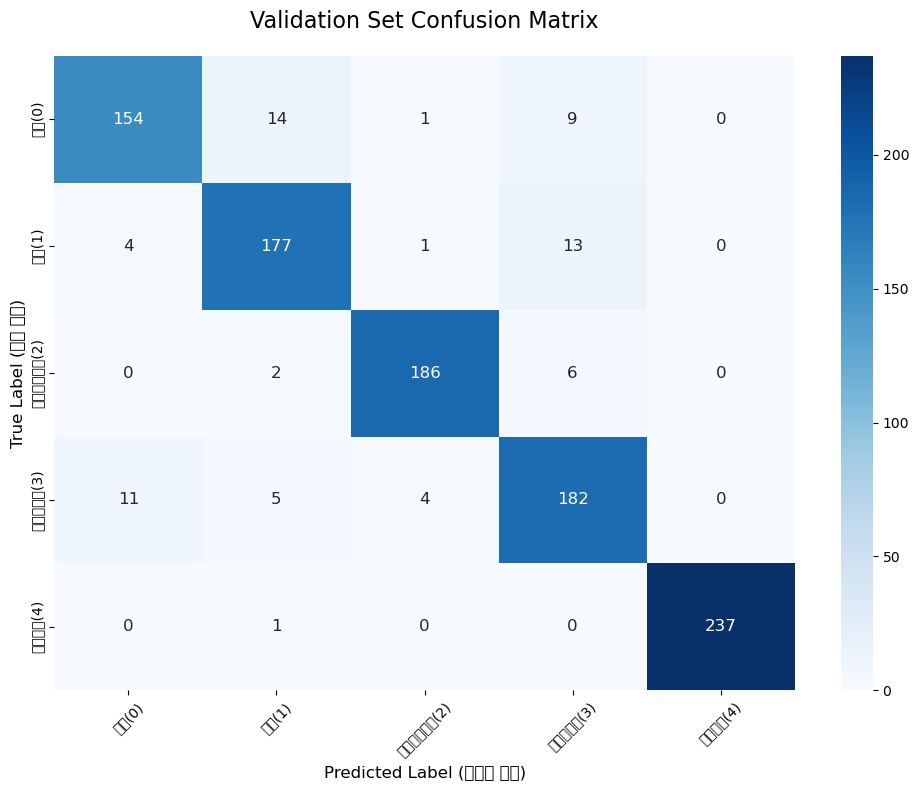


🚨 [모델이 가장 헷갈려하는 오답 쌍 Top 3]
1. 실제는 '협박(0)' 인데, 모델은 '갈취(1)' (으)로 예측한 경우: 14건
2. 실제는 '갈취(1)' 인데, 모델은 '기타괴롭힘(3)' (으)로 예측한 경우: 13건
3. 실제는 '기타괴롭힘(3)' 인데, 모델은 '협박(0)' (으)로 예측한 경우: 11건


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("🚀 Validation 데이터 추론 및 리포트 생성 시작...\n")

# 1. Validation 데이터에 대한 예측 수행
# (위에서 사용하신 trainer와 val_dataset 객체가 메모리에 살아있어야 합니다)
val_predictions = trainer.predict(val_dataset)
preds = np.argmax(val_predictions.predictions, axis=-1)
true_labels = val_predictions.label_ids

# 2. 클래스 이름 매핑 (보기 편하게 한글로 설정)
# 주의: 데이터의 라벨 인덱스와 실제 의미가 맞는지 확인해 주세요.
target_names = ['협박(0)', '갈취(1)', '직장내괴롭힘(2)', '기타괴롭힘(3)', '일반대화(4)']

# ==========================================
# 📋 [1] 클래스별 상세 리포트 (Classification Report)
# ==========================================
print("-" * 55)
print("🎯 [Validation Set 상세 리포트]")
print("-" * 55)
report = classification_report(true_labels, preds, target_names=target_names, digits=4)
print(report)
print("-" * 55)

# ==========================================
# 🗺️ [2] 혼동 행렬 (Confusion Matrix) 시각화
# ==========================================
# (한글 폰트 깨짐 방지 - Colab 환경이라면 'NanumGothic', 로컬 윈도우면 'Malgun Gothic', 맥이면 'AppleGothic')
try:
    plt.rc('font', family='Malgun Gothic') # 윈도우 기준 (맥: AppleGothic)
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names,
            annot_kws={"size": 12}) # 숫자 크기

plt.title('Validation Set Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('True Label (실제 정답)', fontsize=12)
plt.xlabel('Predicted Label (모델의 예측)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# (선택) 혼동 행렬에서 가장 많이 틀린 '오답 Top 3 쌍' 찾기
print("\n🚨 [모델이 가장 헷갈려하는 오답 쌍 Top 3]")
np.fill_diagonal(cm, 0) # 정답(대각선)은 0으로 만들어서 틀린 것만 봅니다.
flat_indices = np.argsort(cm.flatten())[::-1]

count = 0
for idx in flat_indices:
    if cm.flatten()[idx] == 0 or count >= 3:
        break
    true_idx = idx // 5
    pred_idx = idx % 5
    print(f"{count+1}. 실제는 '{target_names[true_idx]}' 인데, 모델은 '{target_names[pred_idx]}' (으)로 예측한 경우: {cm.flatten()[idx]}건")
    count += 1

In [26]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
import torch
import gc

# 1. 원본 데이터 로드
df_pure = pd.read_csv('final_data.csv').dropna(subset=['conversation', 'label'])
test_df = pd.read_csv('./data/test.csv')

# 5-Fold 설정
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Test 예측값들을 모아둘 리스트 (5개 모델의 예측을 더할 예정)
test_preds_list = []

print("🚀 5-Fold Cross Validation 학습 시작 (시간이 5배 걸립니다. 커피 한잔하고 오세요!)")

for fold, (train_idx, val_idx) in enumerate(skf.split(df_pure['conversation'], df_pure['label'])):
    print(f"\n=================== [ Fold {fold + 1}/{N_SPLITS} ] ===================")
    
    # 1. Fold별 데이터 분할
    train_fold = df_pure.iloc[train_idx].reset_index(drop=True)
    val_fold = df_pure.iloc[val_idx].reset_index(drop=True)
    
    # 2. 데이터셋 생성
    train_dataset = KcElectraDataset(train_fold['conversation'].values, train_fold['label'].values, tokenizer, MAX_LENGTH)
    val_dataset = KcElectraDataset(val_fold['conversation'].values, val_fold['label'].values, tokenizer, MAX_LENGTH)
    test_dataset = KcElectraDataset(test_df['conversation'].values, [0]*len(test_df), tokenizer, MAX_LENGTH)
    
    # 3. 모델 초기화 (Fold마다 백지상태 모델 불러오기)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    
    # 4. 트레이너 설정
    training_args.output_dir = f'./results_fold_{fold+1}' # 폴드별 덮어쓰기 방지
    trainer = Trainer(
        model=model, 
        args=training_args,
        train_dataset=train_dataset, 
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics, 
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    
    # 5. 학습 진행
    trainer.train()
    
    # 6. 현재 Fold 모델로 Test 추론 (Logits 저장)
    preds = trainer.predict(test_dataset)
    test_preds_list.append(preds.predictions)
    
    # 🌟 [매우 중요] GPU 메모리 청소 (OOM 에러 방지)
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

# ----------------------------------------------------
# 🌟 [앙상블] 5개 모델의 예측(Logits) 평균 내기
# ----------------------------------------------------
print("\n🔄 5개 모델의 예측값을 병합(Soft Voting) 중...")
ensemble_logits = np.mean(test_preds_list, axis=0)
final_test_preds = np.argmax(ensemble_logits, axis=-1)

# 최종 제출 파일 저장
submission = pd.DataFrame({'idx': test_df['idx'], 'target': final_test_preds})
submission.to_csv('submission_5fold_ensemble.csv', index=False)
print("✅ K-Fold 앙상블 완료! submission_5fold_ensemble.csv 파일이 생성되었습니다.")

🚀 5-Fold Cross Validation 학습 시작 (시간이 5배 걸립니다. 커피 한잔하고 오세요!)

=================== [ Fold 1/5 ] ===================


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.010556,0.784508,0.767755
2,No log,0.406521,0.912612,0.908688
3,No log,0.321026,0.910626,0.907727
4,0.685373,0.269723,0.927507,0.924031
5,0.685373,0.280601,0.918570,0.914986
6,0.685373,0.284974,0.922542,0.918825


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔄 5개 모델의 예측값을 병합(Soft Voting) 중...
✅ K-Fold 앙상블 완료! submission_5fold_ensemble.csv 파일이 생성되었습니다.


In [27]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [일반 대화] 전용 적대적 검증 분석 시작...")

# 1. 데이터 로드 및 '일반 대화(4)'만 필터링
# Train 데이터에서 라벨이 4인 것만 추출
df_train_all = pd.read_csv('final_data.csv').dropna(subset=['conversation', 'label'])
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()

# Test 데이터는 정답을 모르지만, 우리 모델이 '일반 대화'라고 예측했던 것들만 모아서 비교해볼 수 있습니다.
# (또는 Test 전체와 비교하여 Train의 일반대화가 Test 전체 분위기와 얼마나 다른지 봐도 좋습니다.)
# 여기서는 가장 확실한 비교를 위해 Train(일반대화) vs Test(전체) 로 먼저 비교해봅니다.
df_test = pd.read_csv('./data/test.csv')[['conversation']].dropna()

# 2. 적대적 라벨 부여
df_train_normal['adv_target'] = 0  # Train의 일반대화
df_test['adv_target'] = 1         # Test 전체 (혹은 모델이 4로 예측한 Test)

df_adv = pd.concat([df_train_normal, df_test], ignore_index=True)

# 3. TF-IDF 벡터화
vectorizer = TfidfVectorizer(max_features=3000) 
X = vectorizer.fit_transform(df_adv['conversation'])
y = df_adv['adv_target']

# 4. 검증 분할 및 학습
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 5. 결과 출력
preds = clf.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, preds)

print("\n" + "="*50)
print(f"📊 일반 대화 vs Test 전체 AUC: {auc_score:.4f}")
print("="*50)

# 6. 특징 단어 분석 (왜 구분되는가?)
importances = clf.feature_importances_
feature_names = np.array(vectorizer.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [Train 일반대화 vs Test 전체를 가르는 핵심 키워드]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [일반 대화] 전용 적대적 검증 분석 시작...

📊 일반 대화 vs Test 전체 AUC: 0.9770

🔍 [Train 일반대화 vs Test 전체를 가르는 핵심 키워드]
- 죄송합니다 (중요도: 0.0280)
- 내가 (중요도: 0.0248)
- 니가 (중요도: 0.0219)
- 아니 (중요도: 0.0183)
- 그래 (중요도: 0.0161)
- 너가 (중요도: 0.0124)
- 제발 (중요도: 0.0122)
- 제가 (중요도: 0.0121)
- 지금 (중요도: 0.0113)
- 그럼 (중요도: 0.0110)
- 알겠습니다 (중요도: 0.0102)
- 안돼 (중요도: 0.0099)
- ㅋㅋ (중요도: 0.0099)
- 없어요 (중요도: 0.0090)
- 요새 (중요도: 0.0089)


In [28]:
import pandas as pd

# 1. 데이터 로드
df_train = pd.read_csv('final_data.csv').dropna(subset=['conversation'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 분석할 키워드 리스트
keywords = [
    '죄송합니다', '내가', '니가', '아니', '그래', '너가', 
    '제발', '제가', '지금', '그럼', '알겠습니다', '안돼', 'ㅋㅋ', '없어요', '요새'
]

results = []

for word in keywords:
    # Train에서 해당 단어를 포함한 문장 수 및 비율
    train_count = df_train['conversation'].str.contains(word).sum()
    train_ratio = (train_count / len(df_train)) * 100
    
    # Test에서 해당 단어를 포함한 문장 수 및 비율
    test_count = df_test['conversation'].str.contains(word).sum()
    test_ratio = (test_count / len(df_test)) * 100
    
    results.append({
        '키워드': word,
        'Train 빈도(건)': train_count,
        'Train 비중(%)': round(train_ratio, 2),
        'Test 빈도(건)': test_count,
        'Test 비중(%)': round(test_ratio, 2),
        '비중 차이(Test/Train)': round(test_ratio / (train_ratio + 1e-9), 2) # 0나누기 방지
    })

# 결과 출력
analysis_df = pd.DataFrame(results)
# 차이가 큰 순서대로 정렬 (어느 한쪽에 쏠린 정도 확인)
print("🔍 [Train vs Test 키워드 분포 대조 결과]")
display(analysis_df.sort_values(by='비중 차이(Test/Train)', ascending=False))

🔍 [Train vs Test 키워드 분포 대조 결과]


,키워드,Train 빈도(건),Train 비중(%),Test 빈도(건),Test 비중(%),비중 차이(Test/Train)
9,그럼,960,19.07,122,24.4,1.28
5,너가,355,7.05,44,8.8,1.25
10,알겠습니다,286,5.68,35,7.0,1.23
13,없어요,279,5.54,33,6.6,1.19
4,그래,1626,32.29,185,37.0,1.15
7,제가,729,14.48,81,16.2,1.12
8,지금,1086,21.57,117,23.4,1.08
1,내가,1894,37.62,202,40.4,1.07
11,안돼,429,8.52,45,9.0,1.06
2,니가,513,10.19,54,10.8,1.06


In [29]:
import pandas as pd
import random
import torch
from tqdm import tqdm
from transformers import pipeline
from sklearn.model_selection import train_test_split # 데이터 분할 라이브러리 추가

print("🚀 KLUE-BERT 로드 중... (문맥 기반 빈칸 채우기 모델)")
device = 0 if torch.cuda.is_available() else -1
unmasker = pipeline('fill-mask', model='klue/bert-base', device=device)

# --- [전략 1] 협박(0) ↔ 갈취(1) 경계선 스왑 함수 ---
def swap_extortion_threat(text, label):
    money_words = ['돈', '지갑', '입금', '쏴라', '계좌', '알바비', '현금', '수급', '5만원']
    action_words = ['말', '시키는 대로', '비밀', '태도', '행동', '약속']
    
    if label == 1: # 갈취 -> 협박 (금전 목적 제거)
        new_text = text
        changed = False
        for mw in money_words:
            if mw in new_text:
                new_text = new_text.replace(mw, random.choice(action_words))
                changed = True
        return (new_text, 0) if changed else None
    
    elif label == 0: # 협박 -> 갈취 (금전 목적 추가)
        tail = f" 일단 가진 {random.choice(money_words)}이라도 다 내놔라."
        return (text + tail, 1)
    return None

# --- [전략 2] 기타 괴롭힘(3) 하위 카테고리별 증폭 함수 ---
def intensify_other_categories(text):
    p1_map = {'머리': '대가리', '얼굴': '면상', '바보': '지능 떨어지는 놈', '찐따': '개찐따'}
    p2_map = {'때려': '피 터지게 패', '죽어': '뒈져버려', '괴롭': '피를 말려'}
    p3_map = {'기분 나빠': '상종하기도 싫고 토 나와', '꺼져': '사회에서 매장시켜버릴 테니까 꺼져'}
    
    all_maps = {**p1_map, **p2_map, **p3_map}
    new_text = text
    changed = False
    for k, v in all_maps.items():
        if k in new_text:
            new_text = new_text.replace(k, v)
            changed = True
    return new_text if changed else None

# --- [공통] 안전한 문맥 증강 (보호 단어 제외 후 MASK 처리) ---
def safe_contextual_augment(text):
    protected = ['돈', '지갑', '계좌', '죽여', '패', '대가리', '면상', '매장', '신고']
    words = text.split()
    if len(words) < 4: return text
    
    safe_indices = [i for i, w in enumerate(words) if not any(p in w for p in protected)]
    if not safe_indices: return text
    
    replace_idx = random.choice(safe_indices)
    original_word = words[replace_idx]
    words[replace_idx] = '[MASK]'
    masked_text = " ".join(words)
    
    try:
        preds = unmasker(masked_text, top_k=5)
        for p_res in preds:
            token = p_res['token_str'].replace("##", "")
            if token not in original_word and len(token) > 0:
                words[replace_idx] = token
                break
        return " ".join(words)
    except:
        return text

# ==========================================
# 🚨 [수정된 부분] 데이터 누수 방지를 위한 처리
# ==========================================

# 1. 원본 데이터 로드
df_all = pd.read_csv('final_train_data.csv')

# 2. 증강 전에 데이터를 먼저 분할합니다. (Train / Validation)
# stratify=df_all['label'] 을 통해 클래스 비율을 유지합니다.
print("✂️ Train / Validation 데이터 분할 중...")
df_train, df_val = train_test_split(df_all, test_size=0.15, random_state=42, stratify=df_all['label'])

# --- 🚀 메인 증강 루프 실행 (오직 df_train 에만 적용) ---
aug_data = []
AUG_RATIO = 0.4 # 증강 비율

print(f"🔄 전략 기반 하이브리드 증강 시작 (비율: {AUG_RATIO*100}%)...")

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    text = str(row['conversation'])
    label = row['label']
    
    if random.random() < AUG_RATIO:
        # 1. 협박/갈취 경계 학습
        if label in [0, 1]:
            res = swap_extortion_threat(text, label)
            if res:
                final_text = safe_contextual_augment(res[0])
                aug_data.append({'conversation': final_text, 'label': res[1]})
                continue

        # 2. 기타 괴롭힘(3) 하위 카테고리 강화
        if label == 3:
            intensified = intensify_other_categories(text)
            if intensified:
                final_text = safe_contextual_augment(intensified)
                aug_data.append({'conversation': final_text, 'label': 3})
                continue
        
        # 3. 그 외 기본 증강
        basic_aug = safe_contextual_augment(text)
        if basic_aug != text:
            aug_data.append({'conversation': basic_aug, 'label': label})

# 3. 데이터 통합 및 저장 (Train과 Val을 각각 저장)
df_aug = pd.DataFrame(aug_data)
df_final_train = pd.concat([df_train, df_aug], ignore_index=True)
df_final_train = df_final_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Train과 Validation을 별도의 파일로 저장 (가장 안전)
df_final_train.to_csv('train_augmented.csv', index=False)
df_val.to_csv('validation_unseen.csv', index=False)

print(f"\n✅ 증강 및 데이터 분리 완료 (데이터 누수 없음)!")
print(f"✔️ 순수 검증용(Validation) 데이터: {len(df_val)}개 보존 완료")
print(f"✔️ 학습용(Train) 데이터 원본: {len(df_train)}개 -> 증강 후: {len(df_final_train)}개 (추가됨: {len(df_aug)}개)")

🚀 KLUE-BERT 로드 중... (문맥 기반 빈칸 채우기 모델)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✂️ Train / Validation 데이터 분할 중...
🔄 전략 기반 하이브리드 증강 시작 (비율: 40.0%)...


100%|██████████| 4029/4029 [00:30<00:00, 130.30it/s]



✅ 증강 및 데이터 분리 완료 (데이터 누수 없음)!
✔️ 순수 검증용(Validation) 데이터: 711개 보존 완료
✔️ 학습용(Train) 데이터 원본: 4029개 -> 증강 후: 5642개 (추가됨: 1613개)


In [30]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# 1. 데이터 로드
df_train_all = pd.read_csv('final_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 학습된 KcELECTRA 모델 및 토크나이저 로드 (경로는 본인의 모델 저장 경로로 수정)
model_path = "beomi/KcELECTRA-base-v2022" # 또는 학습 후 저장한 모델 경로 './saved_model'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# 3. Test 데이터 추론 (가상 라벨링)
pseudo_labels = []

print("🚀 [Step 1] KcELECTRA 모델로 Test 데이터 가상 라벨링 중...")
with torch.no_grad():
    for text in tqdm(df_test['conversation']):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding="max_length").to(device)
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()
        pseudo_labels.append(pred)

df_test['pseudo_label'] = pseudo_labels

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

🚀 [Step 1] KcELECTRA 모델로 Test 데이터 가상 라벨링 중...


100%|██████████| 500/500 [00:15<00:00, 33.07it/s]


In [32]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

print("🚀 [Step 1] 5-Fold 앙상블 결과(가상 라벨) 로드 중...")

# 1. 원본 Train, Test 데이터 로드
df_train_all = pd.read_csv('final_data.csv').dropna(subset=['conversation', 'label'])
df_test = pd.read_csv('./data/test.csv').dropna(subset=['conversation'])

# 2. 🌟 방금 학습해서 만든 5-Fold 앙상블 결과 로드
try:
    df_sub = pd.read_csv('submission_5fold_ensemble.csv')
    df_test['pseudo_label'] = df_sub['target']
except FileNotFoundError:
    print("❌ 에러: 'submission_5fold_ensemble.csv' 파일을 찾을 수 없습니다. 5-Fold 학습 코드를 먼저 실행해주세요!")
    exit()

print("\n🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...")

# 3. Train(합성 일반)과 Test(5-Fold 앙상블이 4로 예측한 실제 일반) 추출
df_train_normal = df_train_all[df_train_all['label'] == 4][['conversation']].copy()
df_test_normal = df_test[df_test['pseudo_label'] == 4][['conversation']].copy()

print(f"- Train 일반 대화 (합성) 수: {len(df_train_normal)}")
print(f"- Test 일반 대화 (앙상블 예측) 수: {len(df_test_normal)}")

# 4. 적대적 라벨 부여 (0: Train 합성 데이터, 1: Test 실제 데이터)
df_train_normal['adv_target'] = 0  
df_test_normal['adv_target'] = 1   

df_adv = pd.concat([df_train_normal, df_test_normal], ignore_index=True)

# 5. TF-IDF 벡터화 및 Random Forest 학습
vectorizer_adv = TfidfVectorizer(max_features=3000) 
X_adv = vectorizer_adv.fit_transform(df_adv['conversation'])
y_adv = df_adv['adv_target']

X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)
clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train_adv, y_train_adv)

# 6. 검증 결과(AUC) 출력
preds_adv = clf_adv.predict_proba(X_val_adv)[:, 1]
auc_score = roc_auc_score(y_val_adv, preds_adv)

print("\n" + "="*50)
print(f"📊 Train(합성 일반) vs Test(5-Fold 예측 일반) AUC: {auc_score:.4f}")
print("="*50)

# 7. 핵심 키워드 분석 (합성 데이터 수정의 힌트)
importances = clf_adv.feature_importances_
feature_names = np.array(vectorizer_adv.get_feature_names_out())
indices = np.argsort(importances)[::-1][:15]

print("\n🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]")
for i in indices:
    print(f"- {feature_names[i]} (중요도: {importances[i]:.4f})")

🚀 [Step 1] 5-Fold 앙상블 결과(가상 라벨) 로드 중...

🚀 [Step 2] '일반 대화(4)' 전용 적대적 검증 분석 시작...
- Train 일반 대화 (합성) 수: 1190
- Test 일반 대화 (앙상블 예측) 수: 27

📊 Train(합성 일반) vs Test(5-Fold 예측 일반) AUC: 0.9495

🔍 [합성 데이터에서 유독 튀는/부족한 핵심 키워드 Top 15]
- 저기 (중요도: 0.0273)
- 알겠습니다 (중요도: 0.0227)
- 화가 (중요도: 0.0202)
- 있나요 (중요도: 0.0185)
- 기분이 (중요도: 0.0177)
- 기다려 (중요도: 0.0152)
- 입은 (중요도: 0.0115)
- 최대한 (중요도: 0.0109)
- 사람이 (중요도: 0.0107)
- 지금 (중요도: 0.0103)
- 자기가 (중요도: 0.0102)
- 여기서 (중요도: 0.0101)
- 위해 (중요도: 0.0099)
- 그런 (중요도: 0.0093)
- 지금까지 (중요도: 0.0092)
